In [75]:
import matplotlib.pyplot as plt

In [76]:
import pandas as pd

def alphaCalc(N):
    return 2 / (N + 1)

data = pd.read_csv('Data.csv')
data

,Date,Open,High,Low,Close
0,02/28/2025,0.2056,0.2075,0.1815,0.2016
1,02/27/2025,0.2046,0.2112,0.2008,0.2056
2,02/26/2025,0.2121,0.2143,0.1960,0.2040
3,02/25/2025,0.2190,0.2190,0.1957,0.2123
4,02/24/2025,0.2422,0.2439,0.2190,0.2195
...,...,...,...,...,...
362,03/03/2024,0.1421,0.1554,0.1250,0.1536
363,03/02/2024,0.1410,0.1508,0.1364,0.1421
364,03/01/2024,0.1205,0.1410,0.1145,0.1410
365,02/29/2024,0.1137,0.1351,0.1116,0.1203


In [77]:
def subArrays(arr1, arr2):
    resultArr = []
    length = len(arr1)
    if len(arr2)<length:
        length = len(arr2)
    for i in range(0, length):
        resultArr.append(arr1[i]-arr2[i])
    return resultArr

In [78]:
def EMA_element_calc(data, N, nmb_of_curr_elem):
    alpha=alphaCalc(N)
    emaNumerator = data[nmb_of_curr_elem]
    emaDenominator =1
    for j in range(1,nmb_of_curr_elem):
        emaNumerator += ((1-alpha)**j)*data[nmb_of_curr_elem-j]
        emaDenominator += (1-alpha)**j
    return emaNumerator/emaDenominator


In [79]:

def EMA_calc(data, N):
    EMAs_array = []
    for i in range(0,len(data)): #through all numbers
        emaElem =0
        if i<N: #check if actual address in array is less than N then nmb of elements equals i
            emaElem = EMA_element_calc(data, N, i)
        else: #if actual address higher or equal to N then nmb of elements equals N
            emaElem = EMA_element_calc(data, N, N)
        EMAs_array.append(emaElem)
    return EMAs_array


In [80]:
def toFloats(array):
    float_array = []
    for i in array:
        item = float(i.replace(',',''))
        float_array.append(item)
    return float_array

In [81]:
def intersectionPoints(MACD, SIGNAL):
    intersection = []
    buy = []
    sell = []
    for i in range(1, len(MACD)): #skip first because there is no way to analyse if it would be buy or sell
        if MACD[i]==SIGNAL[i]:
            intersection.append(i) #add id in MACD array to intersection array
            if MACD[i-1]>SIGNAL[i-1]:
                sell.append(i)
            else:
                buy.append(i)       
    return intersection, buy, sell

In [82]:


data_from_csv = pd.read_csv('Data.csv')
data_for_calc = data_from_csv['Close']

data_for_calc

0      0.2016
1      0.2056
2      0.2040
3      0.2123
4      0.2195
        ...  
362    0.1536
363    0.1421
364    0.1410
365    0.1203
366    0.1139
Name: Close, Length: 367, dtype: float64

In [83]:
#data_for_calc = toFloats(data_for_calc)


In [84]:
EMA12 = EMA_calc(data_for_calc, 12)
EMA26 = EMA_calc(data_for_calc,26)
MACD = subArrays(EMA12,EMA26)
SIGNAL = EMA_calc(MACD,9)

In [85]:
intersectPoints, buyArray, sellArray = intersectionPoints(MACD, SIGNAL)


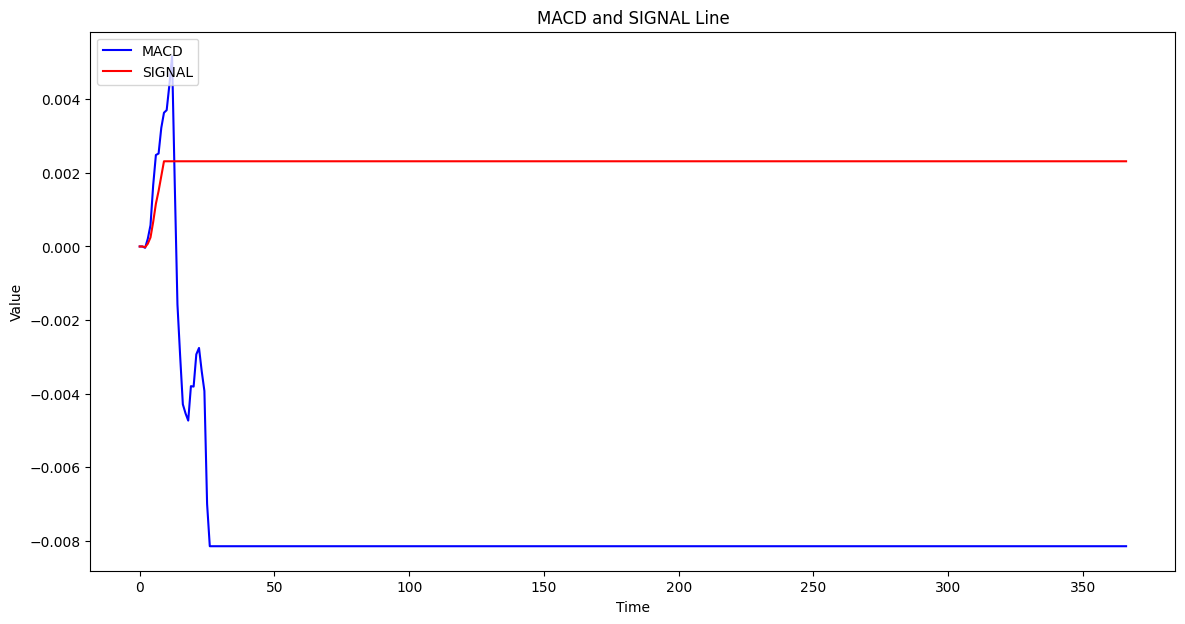

In [86]:
plt.figure(figsize=(14,7))
plt.plot(MACD, label='MACD', color='blue')
plt.plot(SIGNAL, label='SIGNAL', color='red')

plt.legend(loc='upper left')
plt.title('MACD and SIGNAL Line')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()